# Reinforcement Learning: Holding a Heated Plate at a Target Temperature

A square plate of side $W = 0.1$ m has its four edges held at $T_e = 20$ C and a heater covering the middle ninth of its area. The heater is a source term $S$, in C/s, added to the temperature equation over that square:

$$\frac{\partial T}{\partial t} = D\,\nabla^2 T + S(t)\,\chi(x, y), \qquad D = 10^{-4}\ \mathrm{m^2/s},$$

where $\chi$ is one inside the heater and zero outside. The plate starts at 20 C, and at full power, $S = 4$ C/s, the middle ends near 31 C.

The task is to hold the middle at $T^{*} = 25\ \mathrm{C}$ instead. Every 2 s a controller reads the plate, the temperature at the middle and the mean over the whole plate, and chooses $S$ between 0 and 4 C/s, for 15 steps, so an episode is 30 s. Each step is scored by how far the middle stayed from the target while the step lasted,

$$r_k = -\left|\bar{T}_k - T^{*}\right|,$$

where $\bar{T}_k$ is the average of the middle temperature over step $k$. The return of an episode is the sum of the 15 rewards. It is a temperature, in C: a return of zero would mean the middle never left the target, and $-6$ means it spent the episode 0.4 C away on average.

The same task is solved by the exact solution of the plate and by a policy trained with reinforcement learning.

Both reach the solver by the same route. Whatever the controller is, it leaves Python as an ONNX file, and `uqtopusSource` evaluates it while the case runs and applies its action to the heater.

In [1]:
%%capture
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import onnxruntime as ort
import torch as th

import uqtopus as uqt
import uqtopus.rl as rl
from uqtopus.rl.algos import PPO

W, D, EDGE, TARGET = 0.1, 1e-4, 20.0, 25.0
INTERVAL, STEPS = 2.0, 15
root = Path("experiments/heatedPlate")

## 1. The problem without control

With no controller rendered, the template fixes the heater at the `S` value setted by the user.

In [3]:
exp_config = {
    "input_path": "templates/heatedPlate",
    "output_path": str(root / "uncontrolled"),
    "solver": "Allrun",
}
uqt.run_simulation(params={"constant__fvModels__S": 4.0, "system__controlDict__controller": ""}, exp_config=exp_config)

uncontrolled = uqt.parse_openfoam_case(case_dir=exp_config["output_path"], variables=["T"])
uncontrolled

<xarray.Dataset> Size: 445kB
Dimensions:  (time: 11, cell: 3969)
Coordinates:
  * time     (time) float64 88B 0.0 3.0 6.0 9.0 12.0 ... 21.0 24.0 27.0 30.0
    x        (cell) float64 32kB 0.0007937 0.002381 0.003968 ... 0.09762 0.09921
    y        (cell) float64 32kB 0.0007937 0.0007937 ... 0.09921 0.09921
    z        (cell) float64 32kB 0.0008333 0.0008333 ... 0.0008333 0.0008333
Dimensions without coordinates: cell
Data variables:
    T        (time, cell) float64 349kB 20.0 20.0 20.0 20.0 ... 20.02 20.01 20.0

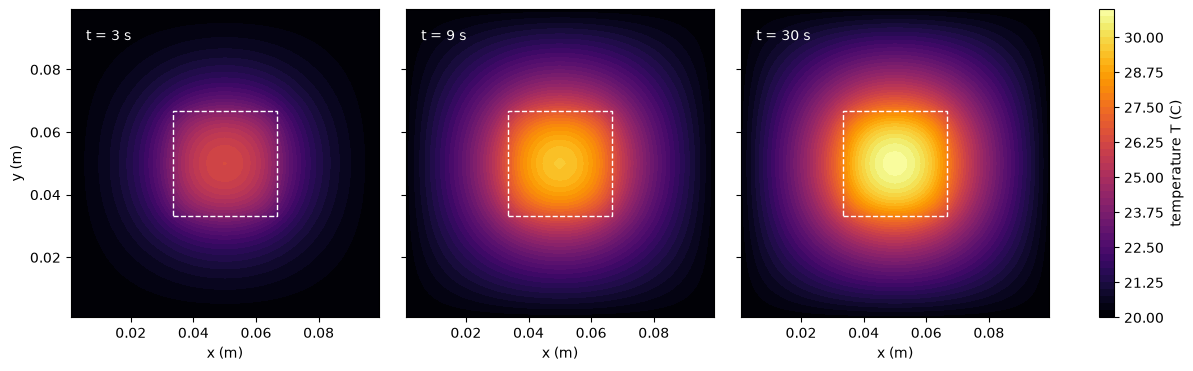

In [4]:
x, y = uncontrolled.x.values, uncontrolled.y.values
levels = np.linspace(EDGE, np.ceil(float(uncontrolled['T'].max())), 45)

fig, axs = plt.subplots(1, 3, figsize=(12, 3.6), sharey=True, constrained_layout=True)
for ax, t in zip(axs, [3, 9, 30]):
    image = ax.tricontourf(x, y, uncontrolled["T"].sel(time=t), levels=levels, cmap="inferno")
    ax.add_patch(plt.Rectangle((W / 3, W / 3), W / 3, W / 3, fill=False, color="white", linestyle="--"))
    ax.text(0.05, 0.9, f"t = {t} s", transform=ax.transAxes, color="white")
    ax.set_xlabel("x (m)")
    ax.set_aspect("equal")
axs[0].set_ylabel("y (m)")
fig.colorbar(image, ax=axs, label="temperature T (C)")
plt.show()

## 2. What the plate does with $S$

$S$ is the number the controller sets: degrees per second added to the temperature equation inside the heater square, and the only thing in the case that moves. To choose it, a controller needs two things about the plate, how much temperature a given $S$ is worth once everything settles, and how long the plate takes to get there. Both come from the textbook solution of the heat equation on a rectangle with the edges held fixed, by eigenfunction expansion ([Kreider, Kuller, Ostberg and Perkins, *An Introduction to Linear Analysis*, Addison-Wesley, 1966](https://openlibrary.org/works/OL27973223W); in its heat conduction form, [Hahn and Ozisik, *Heat Conduction*, 3rd ed.](https://onlinelibrary.wiley.com/doi/book/10.1002/9781118411285)).

Measured from the edges, $u = T - T_e$, the field is a sum of shapes that vanish on the boundary,

$$u(x, y, t) = \sum_{mn} c_{mn}(t)\,\sin\frac{m\pi x}{W}\,\sin\frac{n\pi y}{W},$$

one shape for every pair of integers, $m$ counting the half waves along $x$ and $n$ along $y$, with $m = n = 1$ the single bump over the whole plate. Each shape evolves on its own,

$$\dot{c}_{mn} = -D\lambda_{mn}\,c_{mn} + S(t)\,g_{mn}, \qquad \lambda_{mn} = \frac{\pi^2}{W^2}\left(m^2 + n^2\right),$$

decaying at its own rate $D\lambda_{mn}$, the finer the shape the faster, and driven by how much of the heater square lands on it, $g_{mn} = (4/W^2)\,I_m I_n$ with $I_k$ the integral of $\sin(k\pi x/W)$ across the heater. That integral vanishes for even $k$, so a heater centred on the plate drives the odd shapes alone, which is why the cell below sweeps odd $k$.

With $S$ held constant over a control step each shape relaxes exponentially, which is what advances an episode. The three numbers the rest of the notebook needs come out of the same sum: the steady gain of the middle, the fraction of a deviation that survives one control step, and the $S$ that holds the target.


In [5]:
k = np.arange(1, 100, 2)
m, n = np.meshgrid(k, k, indexing="ij")

rate = D * np.pi**2 * (m**2 + n**2) / W**2
overlap = W / (k * np.pi) * (np.cos(k * np.pi / 3) - np.cos(2 * k * np.pi / 3))
gain = 4 / W**2 * np.outer(overlap, overlap)
middle = np.sin(m * np.pi / 2) * np.sin(n * np.pi / 2)

steady_gain = float(np.sum(middle * gain / rate))
keep = float(np.exp(-rate[0, 0] * INTERVAL))
hold = (TARGET - EDGE) / steady_gain
steady_gain, keep, hold

(2.728007051756302, 0.6738254512314336, 1.8328398369721879)

## 3. Policy spec

What the policy sees, what it drives and how often. The target `heater` is the entry of `constant/fvModels` that takes the action.

The observation has two parts, and they reach the network by different routes:
- `ProbeSource` is a point of a field, interpolated by the solver during the step. 
- `RegistrySource` is a scalar the case computed itself and published under a name, here the mean of $T$ over the plate, which is a property of the whole field and no probe can measure*.

*_A `coded` function object in `system/controlDict` computes it every step and stores it in the mesh registry under `plateMean`, and the controller reads it from there._
```cpp
plateMean
{
    type            coded;
    libs            ("libutilityFunctionObjects.so");

    codeRead
    #{
        if (!mesh().foundObject<uniformDimensionedScalarField>("plateMean"))
        {
            uniformDimensionedScalarField* mean = new uniformDimensionedScalarField
            (
                IOobject("plateMean", mesh().time().constant(), mesh()),
                dimensionedScalar(dimTemperature, 0)
            );
            mean->store();
        }
    #};

    codeExecute
    #{
        const volScalarField& T = mesh().lookupObject<volScalarField>("T");

        mesh().lookupObjectRef<uniformDimensionedScalarField>("plateMean").value() =
            gSum(T.primitiveField()*mesh().V())/gSum(mesh().V());
    #};
}
```

`codeRead` runs once, when the case is read, and creates the scalar, because the controller looks it up by name and something has to put it there. `codeExecute` runs every time step and is the only part that is about this quantity: any average, flux or running total the case can compute goes in those two lines.


In [6]:
spec = rl.PolicySpec(
    observation=rl.ObservationSpec(
        sources=(
            rl.ProbeSource(field_name="T", positions=[(0.05, 0.05, 0.0008)], name="middle"),
            rl.RegistrySource(name="plateMean"),
        )
    ),
    action=rl.ActionSpec(name="S", targets="heater", low=0.0, high=4.0),
    control_interval=INTERVAL,
)
spec

PolicySpec(obs_dim=2, act_dim=1, dt=2.0, hash=f9e5ec0b26e1e3ba)

## 4. The ONNX policy

The network leaves Python as an ONNX file with the spec stamped in its metadata. The graph takes the observation and one standard normal draw, and returns the action; a zero draw returns the mean.

In [7]:
untrained = rl.export_random_policy(spec, root / "policy_untrained.onnx", seed=0)
rl.read_metadata(untrained.path)

{'uqtopus.spec_hash': 'f9e5ec0b26e1e3ba',
 'uqtopus.spec': '{"action": {"high": [4.0], "low": [0.0], "n_components": 1, "name": "S", "ramp_fraction": 0.0, "targets": ["heater"]}, "control_interval": 2.0, "end_time": null, "observation": {"sources": [{"components": null, "field_name": "T", "interpolation": "cellPoint", "kind": "probe", "name": "middle", "positions": [[0.05, 0.05, 0.0008]]}, {"kind": "registry", "name": "plateMean"}]}, "start_time": 0.0}',
 'uqtopus.obs_dim': '2',
 'uqtopus.act_dim': '1',
 'uqtopus.action_low': '0.0',
 'uqtopus.action_high': '4.0',
 'uqtopus.control_interval': '2.0',
 'uqtopus.start_time': '0.0',
 'uqtopus.ramp_fraction': '0.0',
 'uqtopus.action_targets': 'heater:0',
 'uqtopus.iteration': '',
 'uqtopus.normalization': '{"mean": [0.0, 0.0], "std": [1.0, 1.0]}'}

## 5. The untrained policy in OpenFOAM

The runner renders the contract, runs the case and reads the trajectory back as an `xr.Dataset`. The `probes` function object writes the temperature at the middle as column `0`; averaged over each control step, it gives the reward.

In [8]:
runner = rl.ClosedLoopRunner(
    uqt.OpenFOAMSimulator(template_path="templates/heatedPlate", solver_script="Allrun",
                          output_path=root / "runs", qoi_variables=["T"]),
    spec,
    reward_fn=lambda ds: -np.abs(ds["0"] - 25.0),
    controller_keys=["system__controlDict__controller", "constant__fvModels__controller"],
    function_objects=["probes"],
)

before = runner.collect(untrained).episodes[0]
before

<xarray.Dataset> Size: 804B
Dimensions:        (time: 15, obs_component: 2, act_component: 1)
Coordinates:
  * time           (time) float64 120B 2.0 4.0 6.0 8.0 ... 24.0 26.0 28.0 30.0
  * obs_component  (obs_component) <U10 80B 'middle.T.0' 'plateMean'
  * act_component  (act_component) <U1 4B 'S'
Data variables:
    observation    (time, obs_component) float64 240B 20.0 20.0 ... 20.73 20.25
    action         (time, act_component) float64 120B -0.2437 1.315 ... -0.3459
    0              (time) float64 120B 20.0 21.04 21.03 ... 21.09 20.97 20.56
    reward         (time) float64 120B -4.999 -3.961 -3.972 ... -4.034 -4.443
Attributes:
    spec_hash:  f9e5ec0b26e1e3ba
    seed:       0
    source:     experiments/heatedPlate/runs/policy_untrained_ep00/postProces...
    case_dir:   experiments/heatedPlate/runs/policy_untrained_ep00
    diverged:   False

## 6. A control law from the exact solution

A controller answers the reverse question: which $S$ brings the temperature where it should be, decided with what is on hand at that moment. Inverting the whole series would take the amplitude of every shape, while the controller is handed two readings of the instant and carries nothing from one decision to the next.

Keep the slowest shape alone, and give it the steady gain $K$ of the whole series so that the temperature it aims at is the right one. The state of that model is the temperature the probe reads, which is exactly what the controller is handed, and one control step of it reads

$$T^{+} = T_e + \left(T - T_e\right) e^{-D\lambda_{11}\Delta} + K\,S\,\left(1 - e^{-D\lambda_{11}\Delta}\right).$$

Asking for $T^{+}$ to be the target gives the power to apply,

$$S = \frac{\left(T^{*} - T_e\right) - \left(T - T_e\right)e^{-D\lambda_{11}\Delta}}{K\left(1 - e^{-D\lambda_{11}\Delta}\right)},$$

a straight line in the temperature it reads, with nothing left to tune. The cell below writes it as a torch module, exports it through the same `export_policy` a trained network goes through, and asks the exported graph what it would do at four temperatures.


In [9]:
class OneStepLaw(th.nn.Module):
    # raw head of a policy: the action above as the mean, and a spread small enough to be a point

    def __init__(self, gain, keep):
        super().__init__()
        self.gain, self.keep = gain, keep

    def forward(self, observation):
        probe = observation[:, :1]
        action = (TARGET - EDGE - (probe - EDGE) * self.keep) / (self.gain * (1 - self.keep))
        return action, th.full_like(action, -10.0)


exact_policy = rl.export_policy(OneStepLaw(steady_gain, keep), spec, root / "policy_exact.onnx")

session = ort.InferenceSession(str(exact_policy.path), providers=["CPUExecutionProvider"])
np.column_stack([
    [20.0, 24.0, 25.0, 26.0],
    [session.run(None, {"observation": np.array([[value, 21.0]], np.float32), "noise": np.zeros((1, 1), np.float32)})[0][0, 0]
     for value in (20.0, 24.0, 25.0, 26.0)],
])

array([[20.        ,  5.61919975],
       [24.        ,  2.59011173],
       [25.        ,  1.83283985],
       [26.        ,  1.07556808]])

> **The trivial half.** Staying at the target needs no controller at all: the plate sits there under the constant $S = 1.83$ C/s that section 2 computed, the target divided by the steady gain. What the score charges is the climb, and that is the half a controller answers.


## 7. Training

Every iteration exports the current policy, runs four episodes with it at once, and updates the network on what they wrote.

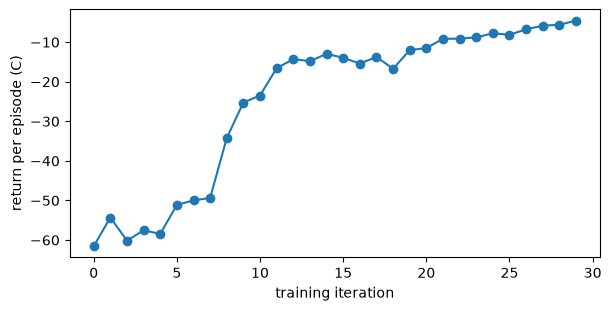

In [10]:
model = PPO("MlpPolicy", runner, n_episodes=4, n_jobs=4, export_dir=root / "policies",
            learning_rate=3e-3, batch_size=30, n_epochs=20, gamma=0.9,
            policy_kwargs={"net_arch": [32, 32]}, seed=0)
model.learn(total_timesteps=30 * 4 * STEPS)
trained = model.export_current_policy(root / "policy_trained.onnx")

fig, ax = plt.subplots(figsize=(6, 3), constrained_layout=True)
ax.plot(model.returns_history, "o-")
ax.set_xlabel("training iteration")
ax.set_ylabel("return per episode (C)")
plt.show()

## 8. Comparison

The two that matter are the law from the exact solution and the trained policy. The untrained network is there to say what the training was worth.

Each runs once, deterministic: the solver feeds the network a zero draw, so it applies the mean of its distribution.


In [11]:
for name, artifact in (("exact", exact_policy), ("trained", trained)):
    block = rl.render_controller(spec, artifact.path.resolve(), deterministic=True)
    uqt.run_simulation(
        params={"system__controlDict__controller": block, "constant__fvModels__controller": block},
        exp_config={"input_path": "templates/heatedPlate", "output_path": str(root / name), "solver": "Allrun"},
    )

control_times = INTERVAL * np.arange(1, STEPS + 1)
cases = {
    "untrained policy": Path(before.attrs["case_dir"]),
    "mathematical law": root / "exact",
    "trained policy": root / "trained",
}


def score(case):
    # the reward the runner computes, from the probes of a finished run
    aligned = rl.align_to_control(rl.read_function_object(case, "probes")["0"], control_times)
    return float(-np.abs(aligned["0"] - TARGET).sum())


{name: round(score(case), 2) for name, case in cases.items()}

{'untrained policy': -66.64, 'mathematical law': -2.71, 'trained policy': -3.9}

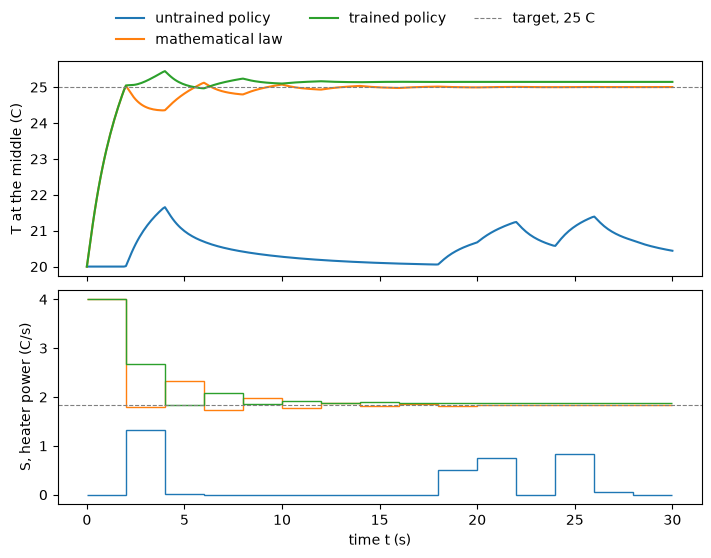

In [12]:
colors = dict(zip(cases, plt.rcParams["axes.prop_cycle"].by_key()["color"]))

fig, axs = plt.subplots(2, 1, figsize=(7, 5.5), sharex=True, constrained_layout=True)
for name, case in cases.items():
    reading = rl.read_function_object(case, "probes")["0"]
    actions = rl.read_trajectory(case, spec)["action"].values[:, 0]
    axs[0].plot(reading.time, reading, color=colors[name], label=name)
    axs[1].stairs(np.clip(actions, 0.0, 4.0), np.r_[0.0, control_times], color=colors[name], baseline=None)
axs[0].axhline(TARGET, color="gray", linestyle="--", linewidth=0.8, label="target, 25 C")
axs[1].axhline(hold, color="gray", linestyle="--", linewidth=0.8)
axs[0].set_ylabel("T at the middle (C)")
axs[1].set_ylabel("S, heater power (C/s)")
axs[1].set_xlabel("time t (s)")
fig.legend(loc="outside upper center", ncol=3, frameon=False)
plt.show()

Both controllers were asked about the middle of the plate alone, and both runs wrote the whole field, so they can also be compared where nobody was looking. The third panel is the difference between the two fields at the end of the run.


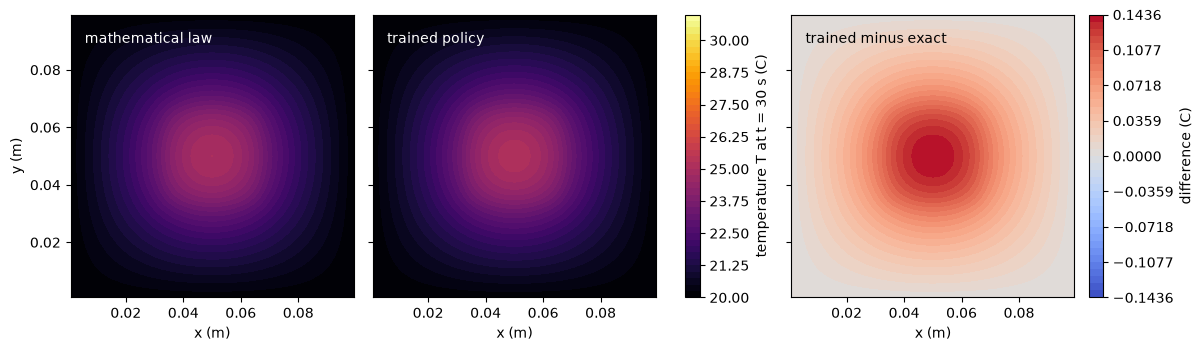

In [13]:
fields = {
    name: uqt.parse_openfoam_case(case_dir=str(cases[name]), variables=["T"])["T"]
    for name in list(cases.keys())[1:]
}
late = fields["trained policy"].time.values[-1]
gap = (fields["trained policy"] - fields["mathematical law"]).sel(time=late).values
span = np.abs(gap).max()

fig, axs = plt.subplots(1, 3, figsize=(12, 3.4), sharey=True, constrained_layout=True)
for ax, (name, field) in zip(axs, fields.items()):
    hot = ax.tricontourf(x, y, field.sel(time=late).values, levels=levels, cmap="inferno")
    ax.text(0.05, 0.9, name, transform=ax.transAxes, color="white")
cool = axs[2].tricontourf(x, y, gap, levels=np.linspace(-span, span, 41), cmap="coolwarm")
axs[2].text(0.05, 0.9, "trained minus exact", transform=axs[2].transAxes, color="black")
for ax in axs:
    ax.set_xlabel("x (m)")
    ax.set_aspect("equal")
axs[0].set_ylabel("y (m)")
fig.colorbar(hot, ax=axs[:2], label=f"temperature T at t = {late:.0f} s (C)")
fig.colorbar(cool, ax=axs[2], label="difference (C)")
plt.show()


## 9. The policy as a map

A trained policy is a function from what it reads to what it does, and here it reads two temperatures, so the whole function fits in one picture. Drawing it over the plane of the two observations is the cheapest thing that deserves the name of interpretation: it says how much power the policy asks for in every state it could be handed, and whether it uses both of the numbers it is given.


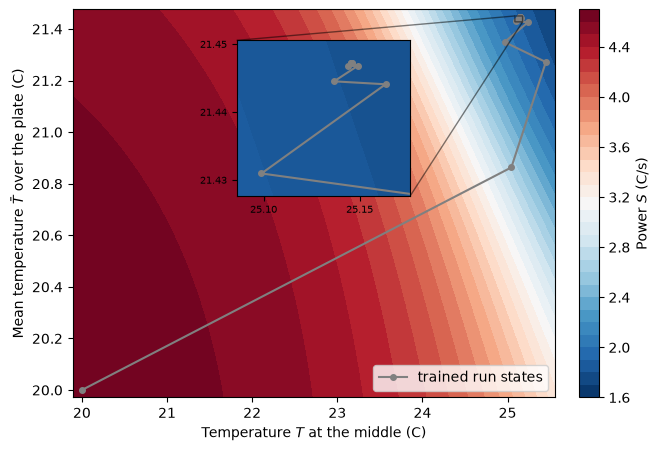

In [14]:
trained_session = ort.InferenceSession(str(trained.path), providers=["CPUExecutionProvider"])
visited = rl.read_trajectory(cases["trained policy"], spec)["observation"].values

margin = 0.02 * np.ptp(visited, axis=0)
probe, plate_mean = np.meshgrid(
    np.linspace(visited[:, 0].min() - margin[0], visited[:, 0].max() + margin[0], 120),
    np.linspace(visited[:, 1].min() - margin[1], visited[:, 1].max() + margin[1], 120),
)
pairs = np.column_stack([probe.ravel(), plate_mean.ravel()]).astype(np.float32)
asked = trained_session.run(
    None, {"observation": pairs, "noise": np.zeros((len(pairs), 1), np.float32)}
)[0][:, 0].reshape(probe.shape)

fig, ax = plt.subplots(figsize=(6.5, 4.4), constrained_layout=True)
response = ax.contourf(probe, plate_mean, asked, levels=33, cmap="RdBu_r")
ax.plot(visited[:, 0], visited[:, 1], "o-", color="gray", markersize=4, label="trained run states")
ax.set_xlabel(r"Temperature $T$ at the middle (C)")
ax.set_ylabel(r"Mean temperature $\bar{T}$ over the plate (C)")
ax.legend(loc="lower right")

# the run spends most of its decisions in a corner of the map
tail = visited[-10:]
pad = 0.2 * np.ptp(tail, axis=0)
zoom = ax.inset_axes([0.34, 0.52, 0.36, 0.40])
zoom.contourf(probe, plate_mean, asked, levels=111, cmap="RdBu_r")
zoom.plot(visited[:, 0], visited[:, 1], "o-", color="gray", markersize=4)
zoom.set_xlim(tail[:, 0].min() - pad[0], tail[:, 0].max() + pad[0])
zoom.set_ylim(tail[:, 1].min() - pad[1], tail[:, 1].max() + pad[1])
zoom.locator_params(nbins=3)
zoom.tick_params(labelsize=7)
ax.indicate_inset_zoom(zoom, edgecolor="black")

fig.colorbar(response, ax=ax, label=r"Power $S$ (C/s)")
plt.show()